## Data Preprocessing

### Objective

The goal of this stage is to:

- Prepare the dataset for machine learning models  
- Handle missing values and correct data types  
- Encode categorical features into numerical format  
- Engineer new features to capture customer behavior and patterns  
- Address multicollinearity and reduce redundant information  
- Scale numerical features if required by the model  
- Ensure data consistency and prevent data leakage  

## Data Loading & Setup
We begin by importing necessary libraries and loading the dataset.

In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [4]:
df = pd.read_csv('../data/raw/telco_churn.csv')

### 1. Data Split

- Perform stratified split based on `Churn`
- Optionally create a validation set  

This ensures fair model evaluation and prevents data leakage.

In [6]:
# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Encode target
y = y.map({'Yes': 1, 'No': 0})

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 2. Data Cleaning

**TotalCharges:**
- Convert to numeric format  
- Handle missing values using domain logic:
  - If `tenure = 0` → set `TotalCharges = 0`  

This is a feature-aware approach rather than simple imputation.


In [8]:
# Convert TotalCharges to numeric
X_train['TotalCharges'] = pd.to_numeric(X_train['TotalCharges'], errors='coerce')
X_test['TotalCharges'] = pd.to_numeric(X_test['TotalCharges'], errors='coerce')

# Apply domain logic: if tenure = 0 → TotalCharges = 0
X_train.loc[X_train['tenure'] == 0, 'TotalCharges'] = 0
X_test.loc[X_test['tenure'] == 0, 'TotalCharges'] = 0
print('Number of missing values in the training set = ',X_train['TotalCharges'].isna().sum())
print('Number of missing values in the test set = ',X_test['TotalCharges'].isna().sum())

Number of missing values in the training set =  0
Number of missing values in the test set =  0


Missing values in TotalCharges are associated with customers having zero tenure.  
Since these customers have not been billed yet, their total charges are logically set to zero. 

### 3. Feature Engineering

#### 3.1 Customer Lifetime Features

- `avg_monthly_spend = TotalCharges / tenure`  

Captures true customer spending behavior and removes time dependency.

In [11]:
import numpy as np

# Avoid division by zero
X_train['avg_monthly_spend'] = np.where(
    X_train['tenure'] > 0,
    X_train['TotalCharges'] / X_train['tenure'],
    0
)

X_test['avg_monthly_spend'] = np.where(
    X_test['tenure'] > 0,
    X_test['TotalCharges'] / X_test['tenure'],
    0
)

The `avg_monthly_spend` feature represents the average amount a customer spends per month.

It normalizes total charges by tenure, removing time dependency and better reflecting true customer spending behavior.

#### 3.2 Tenure Binning

Group customers into segments:
- 0–12 → new  
- 12–36 → mid-term  
- 36+ → loyal  

Reduces noise and captures lifecycle stages.


In [14]:
# Define bins and labels
bins = [0, 12, 36, float('inf')]
labels = ['new', 'mid', 'loyal']

# Create binned feature
X_train['tenure_group'] = pd.cut(X_train['tenure'], bins=bins, labels=labels, right=False)
X_test['tenure_group'] = pd.cut(X_test['tenure'], bins=bins, labels=labels, right=False)

The `tenure_group` feature segments customers into lifecycle stages (new, mid-term, loyal).

This reduces noise in the raw tenure variable and helps the model capture differences in customer behavior across these groups.

#### 3.3 Service Usage Intensity

- Create `num_services` (count of active services)  

Hypothesis: more services → lower churn.

In [17]:
# List of service-related columns
service_cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

In [18]:
# Convert services to binary (1 = has service, 0 = no service)

def count_services(df):
    temp = df[service_cols].copy()
    
    for col in temp.columns:
        temp[col] = temp[col].apply(lambda x: 0 if x in ['No', 'No internet service'] else 1)
    
    return temp.sum(axis=1)

# Apply to train and test
X_train['num_services'] = count_services(X_train)
X_test['num_services'] = count_services(X_test)

The `num_services` feature represents the total number of services a customer is using.

It captures customer engagement, with the hypothesis that customers using more services are more integrated into the ecosystem and therefore less likely to churn.


#### 3.4 Internet & Add-ons Features

- `has_internet` (binary)  
- `has_addons` (sum of additional services)  

Captures dependency between base service and add-ons.

In [21]:
# has_internet: 1 if customer has internet service, else 0
X_train['has_internet'] = X_train['InternetService'].apply(lambda x: 0 if x == 'No' else 1)
X_test['has_internet'] = X_test['InternetService'].apply(lambda x: 0 if x == 'No' else 1)

In [22]:
# List of add-on services (only meaningful if internet exists)
addon_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

In [23]:
# Convert add-ons to binary and count
def count_addons(df):
    temp = df[addon_cols].copy()
    
    for col in temp.columns:
        temp[col] = temp[col].apply(lambda x: 0 if x in ['No', 'No internet service'] else 1)
    
    return temp.sum(axis=1)

X_train['has_addons'] = count_addons(X_train)
X_test['has_addons'] = count_addons(X_test)

The `has_internet` and `has_addons` features capture the relationship between core and additional services.

They reflect whether a customer has a base internet service and how many add-on services are used, indicating the level of engagement and dependency on the product ecosystem.

#### 3.5 Contract Risk Feature

- `risky_contract`:
  - 1 → Month-to-month  
  - 0 → others  

Captures high-risk churn behavior.

In [26]:
# risky_contract: 1 if Month-to-month, else 0
X_train['risky_contract'] = X_train['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)
X_test['risky_contract'] = X_test['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)

The `risky_contract` feature captures customer commitment.

Month-to-month contracts indicate low commitment and higher flexibility, making customers more likely to churn, while long-term contracts suggest greater stability.

#### 3.6 Payment Behavior

- `auto_payment`:
  - 1 → automatic payments  
  - 0 → manual  

Reflects customer commitment and stability.

In [29]:
# Define automatic payment methods
auto_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']

# Create feature
X_train['auto_payment'] = X_train['PaymentMethod'].apply(lambda x: 1 if x in auto_methods else 0)
X_test['auto_payment'] = X_test['PaymentMethod'].apply(lambda x: 1 if x in auto_methods else 0)

The `auto_payment` feature indicates whether a customer uses automatic payment methods.

Customers with automatic payments are typically more stable and less likely to churn, as this reflects higher commitment and lower friction in the billing process.

### 4. Handling Categorical Features

#### 4.1 Binary Features
- Encode as 0/1



In [32]:
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    X_train[col] = X_train[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0})
    X_test[col] = X_test[col].map({'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0})

#### 4.2 Ordinal Encoding

In [34]:
mapping = {'new': 0, 'mid': 1, 'loyal': 2}

X_train['tenure_group'] = X_train['tenure_group'].map(mapping)
X_test['tenure_group'] = X_test['tenure_group'].map(mapping)

In [35]:
contract_map = {
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
}

X_train['Contract'] = X_train['Contract'].map(contract_map)
X_test['Contract'] = X_test['Contract'].map(contract_map)

#### 4.3 One-Hot Encoding

In [37]:
# Columns for one-hot encoding
multi_cols = ['MultipleLines', 'InternetService', 'PaymentMethod']

# concat train and test 
full = pd.concat([X_train, X_test], axis=0)

#  one-hot encoding
full = pd.get_dummies(full, columns=multi_cols, drop_first=True)

# get back
X_train = full.iloc[:len(X_train), :]
X_test = full.iloc[len(X_train):, :]

In [38]:
X_train = X_train.select_dtypes(exclude='object')
X_test = X_test.select_dtypes(exclude='object')

In [39]:
# bool to int
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

### Handling Categorical Features

- Binary features were encoded as 0/1  
- Ordinal encoding was applied to ordered features (e.g., tenure_group, Contract)  
- One-hot encoding was used for multi-category features  
- Train and test sets were aligned to ensure consistent feature space  

### 5. Multicollinearity

- Identify highly correlated features  

Validate using:
- Correlation matrix  

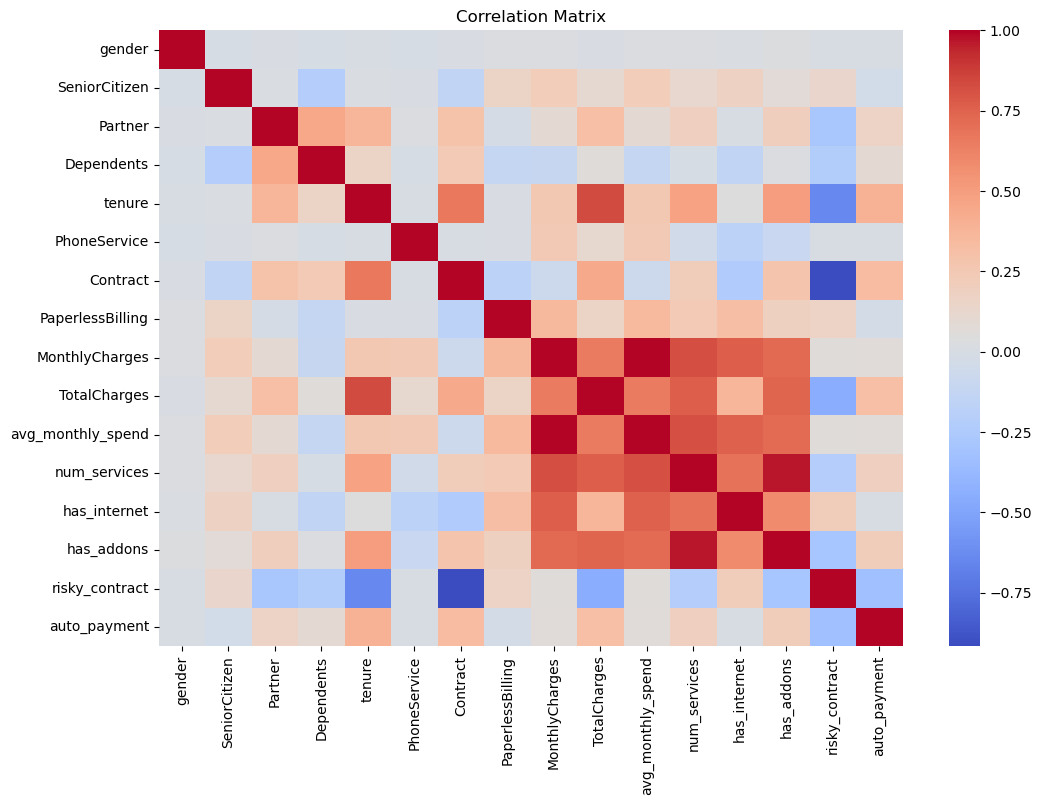

In [42]:
# Select only numerical features
num_features = X_train.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = num_features.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [43]:
# Find highly correlated features (threshold = 0.8)
threshold = 0.8

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname_1 = corr_matrix.columns[i]
            colname_2 = corr_matrix.columns[j]
            high_corr.append((colname_1, colname_2, corr_matrix.iloc[i, j]))

high_corr

[('TotalCharges', 'tenure', 0.8296984390385438),
 ('avg_monthly_spend', 'MonthlyCharges', 0.9946458109959573),
 ('num_services', 'MonthlyCharges', 0.8218121557887975),
 ('num_services', 'avg_monthly_spend', 0.8163919260971151),
 ('has_addons', 'num_services', 0.9668916406256497),
 ('risky_contract', 'Contract', -0.9162227319855183)]

#### Multicollinearity Analysis

Several strong correlations were identified between features:

- `TotalCharges` and `tenure` (0.83) — reflects accumulated payments over time  
- `avg_monthly_spend` and `MonthlyCharges` (0.99) — nearly identical information  
- `num_services` and `has_addons` (0.97) — both capture service usage intensity  
- `risky_contract` and `Contract` (-0.92) — redundant representation of contract type  

These relationships indicate significant multicollinearity, where multiple features encode similar information.

To reduce redundancy and improve model stability:

- One of each highly correlated pair should be removed  
- Preference should be given to more interpretable or engineered features  

This step helps simplify the model and prevent over-reliance on duplicated signals.

### 6. Feature Selection

- Remove:
  - `customerID`  
  - Redundant or highly correlated features  
- Evaluate feature importance using:
  - Model-based methods  
  - Mutual information 

In [46]:
# Drop identifier
X_train = X_train.drop('customerID', axis=1, errors='ignore')
X_test = X_test.drop('customerID', axis=1, errors='ignore')


In [47]:
cols_to_drop = [
    'TotalCharges',        # correlated with tenure
    'MonthlyCharges',      # duplicated by avg_monthly_spend
    'num_services',        # duplicated by has_addons
    'Contract'             # duplicated by risky_contract
]

X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')

In [48]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

importances

avg_monthly_spend                        0.274100
tenure                                   0.213075
risky_contract                           0.078853
has_addons                               0.074412
tenure_group                             0.048520
InternetService_Fiber optic              0.045227
gender                                   0.034269
PaymentMethod_Electronic check           0.033886
PaperlessBilling                         0.031619
Partner                                  0.027610
SeniorCitizen                            0.025278
Dependents                               0.023455
MultipleLines_Yes                        0.023437
auto_payment                             0.014089
PaymentMethod_Credit card (automatic)    0.012764
has_internet                             0.011271
PaymentMethod_Mailed check               0.010109
InternetService_No                       0.008405
PhoneService                             0.005089
MultipleLines_No phone service           0.004532


In [49]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)

mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

mi_series.head

<bound method NDFrame.head of risky_contract                           0.087188
tenure                                   0.063858
tenure_group                             0.055082
InternetService_Fiber optic              0.051592
PaymentMethod_Electronic check           0.045303
InternetService_No                       0.043593
has_internet                             0.041560
auto_payment                             0.035733
avg_monthly_spend                        0.033123
has_addons                               0.033089
PaperlessBilling                         0.021127
Dependents                               0.016961
PaymentMethod_Credit card (automatic)    0.016484
Partner                                  0.011174
MultipleLines_No phone service           0.004440
SeniorCitizen                            0.004295
MultipleLines_Yes                        0.002752
PaymentMethod_Mailed check               0.000908
PhoneService                             0.000000
gender              

### Feature Selection Insights

Feature importance and mutual information analysis show consistent patterns:

- **Top features**:
  - `avg_monthly_spend`
  - `tenure`
  - `risky_contract`
  - `has_addons`
  - `tenure_group`

These features capture key aspects of customer behavior: spending, lifecycle, engagement, and contract risk.

- **Moderately useful features**:
  - `InternetService_Fiber optic`
  - `PaymentMethod_Electronic check`
  - `PaperlessBilling`
  - `Partner`

- **Low-impact features**:
  - `gender`
  - `PhoneService`
  - `MultipleLines_No phone service`
  - `PaymentMethod_Mailed check`

### 7. Scaling

In [52]:
scale_cols = [
    'tenure',
    'avg_monthly_spend',
    'has_addons'
]

In [53]:
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

### Scaling

Numerical features were scaled using StandardScaler to normalize their distributions.

Binary and one-hot encoded features were not scaled, as they are already in a suitable format.

Scaling is particularly important for distance-based and linear models.

### 9. Save the dataset after preprocessing

In [56]:
with open('../data/processed/train_test_data.pkl', 'wb') as f:
    pickle.dump((X_train, X_test, y_train, y_test), f)

## Preprocessing Summary

The preprocessing pipeline successfully transformed raw customer data into a clean, feature-rich dataset optimized for machine learning.

### Key Steps Performed:

1. **Data Splitting**
   - Stratified train/test split (80/20) based on `Churn` to preserve class distribution
   - Target variable encoded as binary (1 = Churn, 0 = No Churn)

2. **Data Cleaning**
   - `TotalCharges` converted from string to numeric
   - Missing values handled with domain logic: when `tenure == 0`, `TotalCharges` set to 0 (customers with no billing history)

3. **Feature Engineering**
   - `avg_monthly_spend` = TotalCharges / tenure — normalizes spending by customer lifetime
   - `tenure_group` — binned tenure into lifecycle stages (new: 0–12, mid: 12–36, loyal: 36+)
   - `num_services` — count of all active services
   - `has_addons` — count of internet add-on services
   - `has_internet` — binary indicator for internet service
   - `risky_contract` — binary indicator for month-to-month contracts (high churn risk)
   - `auto_payment` — binary indicator for automatic payment methods

4. **Categorical Encoding**
   - Binary features → 0/1 mapping
   - Ordinal features (`tenure_group`, `Contract`) → integer encoding preserving order
   - Multi-category features (`MultipleLines`, `InternetService`, `PaymentMethod`) → one-hot encoding with `drop_first`

5. **Multicollinearity & Feature Selection**
   - Correlation matrix revealed strong correlations (threshold > 0.8)
   - Redundant features removed:
     - `TotalCharges` (correlated with `tenure`)
     - `MonthlyCharges` (99% correlated with `avg_monthly_spend`)
     - `num_services` (97% correlated with `has_addons`)
     - `Contract` (92% correlated with `risky_contract`)
   - Feature importance (RandomForest) and mutual information confirmed top predictors: `avg_monthly_spend`, `tenure`, `risky_contract`, `has_addons`

6. **Scaling**
   - `StandardScaler` applied to numerical features (`tenure`, `avg_monthly_spend`, `has_addons`)
   - Scaler fitted on training data only, then transformed test data to prevent data leakage

7. **Final Dataset**
   - `customerID` removed
   - All features now numeric, no missing values
   - Processed data saved to `../data/processed/train_test_data.pkl`

### Outcome
The dataset is now ready for model training with:
- Reduced dimensionality
- No multicollinearity issues
- Meaningful engineered features that capture customer behavior
- Properly scaled numerical features
- Consistent preprocessing between train and test sets